In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
import os
import warnings

warnings.filterwarnings('ignore')

datasets path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
ravdess_path = '/content/drive/MyDrive/SER_Datasets/RAVDESS/'
speech_signal_path = '/content/drive/MyDrive/SER_Datasets/Speech_Features/'
cremad_path = '/content/drive/MyDrive/SER_Datasets/CREMAD/'
savee_path = '/content/drive/MyDrive/SER_Datasets/SAVEE/'
toronto_path = '/content/drive/MyDrive/SER_Datasets/TESS/'

RAVDESS

In [ ]:
ravdess_ls = os.listdir(ravdess_path)
ravdess_ls

['Actor_02',
 'Actor_17',
 'Actor_05',
 'Actor_16',
 'Actor_21',
 'Actor_01',
 'Actor_11',
 'Actor_20',
 'Actor_08',
 'Actor_15',
 'Actor_06',
 'Actor_12',
 'Actor_23',
 'Actor_24',
 'Actor_22',
 'Actor_04',
 'Actor_19',
 'Actor_10',
 'Actor_09',
 'Actor_14',
 'Actor_03',
 'Actor_13',
 'Actor_18',
 'Actor_07']

In [ ]:
file_emotion = []
file_path = []
c = 0
for i in ravdess_ls:
    actor = os.listdir(ravdess_path  + i)
    for f in actor:
        part = f.split('.')[0].split('-')
        file_emotion.append(int(part[2]))
        file_path.append(ravdess_path + i + '/' + f)

In [ ]:
emotions = pd.DataFrame(file_emotion, columns=['Emotions'])
# dataframe for path of files.
paths = pd.DataFrame(file_path, columns=['Path'])
ravdess_df = pd.concat([paths, emotions], axis=1)
# changing integers to actual emotions.
ravdess_df.Emotions.replace({1:'neutral', 2:'neutral', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust',
                             8:'surprise'},
                            inplace=True)

ravdess_df.head()

,Path,Emotions
0,/kaggle/input/ravdess-emotional-speech-audio/a...,surprise
1,/kaggle/input/ravdess-emotional-speech-audio/a...,neutral
2,/kaggle/input/ravdess-emotional-speech-audio/a...,disgust
3,/kaggle/input/ravdess-emotional-speech-audio/a...,disgust
4,/kaggle/input/ravdess-emotional-speech-audio/a...,neutral


In [ ]:
crema_ls = os.listdir(cremad_path)

file_emotion = []
file_path = []

for file in crema_ls:
    # storing file paths
    file_path.append(cremad_path+ file)
    # storing file emotions
    part=file.split('_')
    if part[2] == 'SAD':
        file_emotion.append('sad')
    elif part[2] == 'ANG':
        file_emotion.append('angry')
    elif part[2] == 'DIS':
        file_emotion.append('disgust')
    elif part[2] == 'FEA':
        file_emotion.append('fear')
    elif part[2] == 'HAP':
        file_emotion.append('happy')
    elif part[2] == 'NEU':
        file_emotion.append('neutral')
    else:
        file_emotion.append('Unknown')

# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
cremad_df = pd.concat([path_df, emotion_df], axis=1)
cremad_df.head()

,Path,Emotions
0,/kaggle/input/cremad/AudioWAV/1028_TSI_DIS_XX.wav,disgust
1,/kaggle/input/cremad/AudioWAV/1075_IEO_HAP_LO.wav,happy
2,/kaggle/input/cremad/AudioWAV/1084_ITS_HAP_XX.wav,happy
3,/kaggle/input/cremad/AudioWAV/1067_IWW_DIS_XX.wav,disgust
4,/kaggle/input/cremad/AudioWAV/1066_TIE_DIS_XX.wav,disgust


TORONTO

In [ ]:
tess_ls = os.listdir(toronto_path)

file_emotion = []
file_path = []

for dir in tess_ls:
    directories = os.listdir(toronto_path + dir)
    for file in directories:
        part = file.split('.')[0]
        part = part.split('_')[2]
        if part=='ps':
            file_emotion.append('surprise')
        else:
            file_emotion.append(part)
        file_path.append(toronto_path + dir + '/' + file)

# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
tess_df = pd.concat([path_df, emotion_df], axis=1)
tess_df.head()


,Path,Emotions
0,/kaggle/input/toronto-emotional-speech-set-tes...,fear
1,/kaggle/input/toronto-emotional-speech-set-tes...,fear
2,/kaggle/input/toronto-emotional-speech-set-tes...,fear
3,/kaggle/input/toronto-emotional-speech-set-tes...,fear
4,/kaggle/input/toronto-emotional-speech-set-tes...,fear


SAVEE

In [ ]:
savee_ls = os.listdir(savee_path)

file_emotion = []
file_path = []

for file in savee_ls:
    file_path.append(savee_path+ file)
    part = file.split('_')[1]
    ele = part[:-6]
    if ele=='a':
        file_emotion.append('angry')
    elif ele=='d':
        file_emotion.append('disgust')
    elif ele=='f':
        file_emotion.append('fear')
    elif ele=='h':
        file_emotion.append('happy')
    elif ele=='n':
        file_emotion.append('neutral')
    elif ele=='sa':
        file_emotion.append('sad')
    else:
        file_emotion.append('surprise')

# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
savee_df = pd.concat([ path_df,emotion_df], axis=1)
savee_df.head()


,Path,Emotions
0,/kaggle/input/surrey-audiovisual-expressed-emo...,happy
1,/kaggle/input/surrey-audiovisual-expressed-emo...,fear
2,/kaggle/input/surrey-audiovisual-expressed-emo...,happy
3,/kaggle/input/surrey-audiovisual-expressed-emo...,disgust
4,/kaggle/input/surrey-audiovisual-expressed-emo...,angry


In [ ]:
# creating Dataframe using all the 4 dataframes we created so far.
concate = pd.concat([ravdess_df, cremad_df, tess_df, savee_df], axis = 0)
concate.to_csv("data_path.csv",index=False)
concate.head()

,Path,Emotions
0,/kaggle/input/ravdess-emotional-speech-audio/a...,surprise
1,/kaggle/input/ravdess-emotional-speech-audio/a...,neutral
2,/kaggle/input/ravdess-emotional-speech-audio/a...,disgust
3,/kaggle/input/ravdess-emotional-speech-audio/a...,disgust
4,/kaggle/input/ravdess-emotional-speech-audio/a...,neutral


In [ ]:
print(concate.Emotions.value_counts())


Emotions
disgust     1923
sad         1923
fear        1923
happy       1923
angry       1923
neutral     1895
surprise     652
Name: count, dtype: int64


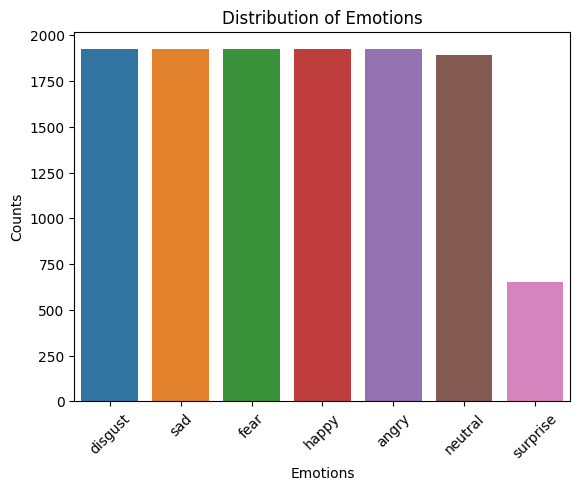

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

emotion_counts = concate.Emotions.value_counts()

sns.barplot(x=emotion_counts.index, y=emotion_counts.values)

plt.xlabel('Emotions')
plt.ylabel('Counts')
plt.title('Distribution of Emotions')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Instead of using file_path[0], use concate['Path'].values[0]
file_path = concate['Path'].values[0]
label = concate['Emotions'].values[0]
# Then load
data, sr = librosa.load(file_path)
print(sr)
print(label)

22050
surprise


In [ ]:
ipd.Audio(data,rate=sr)

CREATE SPECTROGRAM

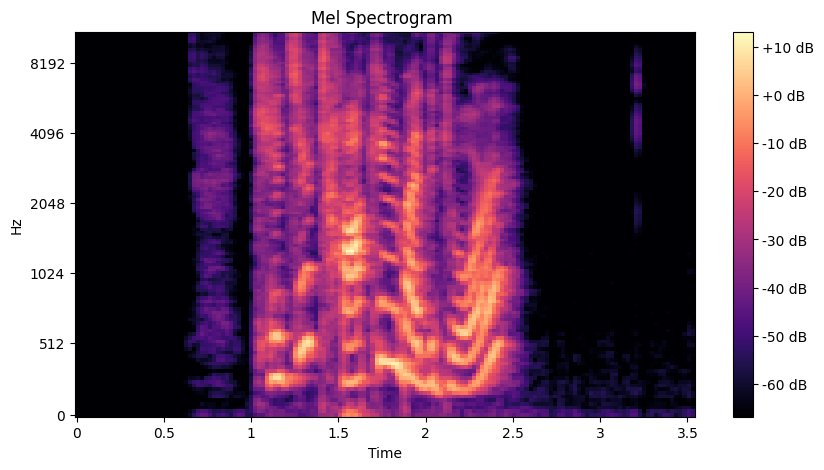

In [ ]:
# CREATE LOG MEL SPECTROGRAM
plt.figure(figsize=(10, 5))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000)
log_spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(log_spectrogram, y_axis='mel', sr=sr, x_axis='time');
plt.title('Mel Spectrogram ')
plt.colorbar(format='%+2.0f dB')

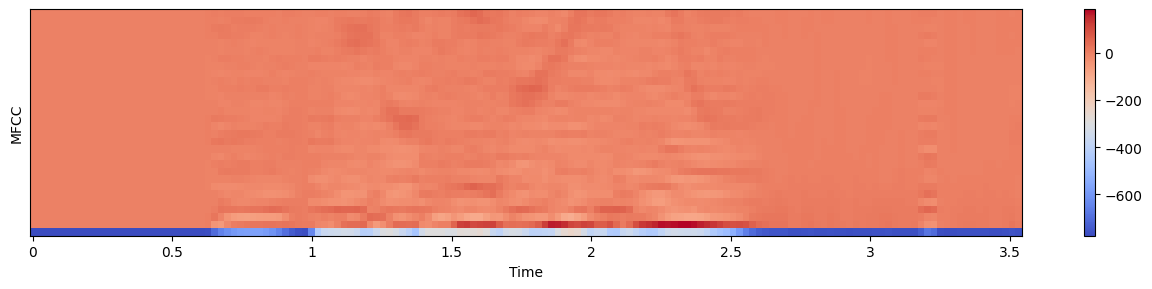

In [ ]:
mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=30)

# MFCC
plt.figure(figsize=(16, 10))
plt.subplot(3,1,1)
librosa.display.specshow(mfcc, x_axis='time')
plt.ylabel('MFCC')
plt.colorbar()

Augmentation

In [ ]:
# NOISE
def noise(data):
    noise_amp = 0.035*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

# STRETCH
def stretch(data, rate=0.8):
    return librosa.resample(data, orig_sr=sr, target_sr=int(sr * rate))

# SHIFT
def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)
# PITCH

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sampling_rate, n_steps=pitch_factor)

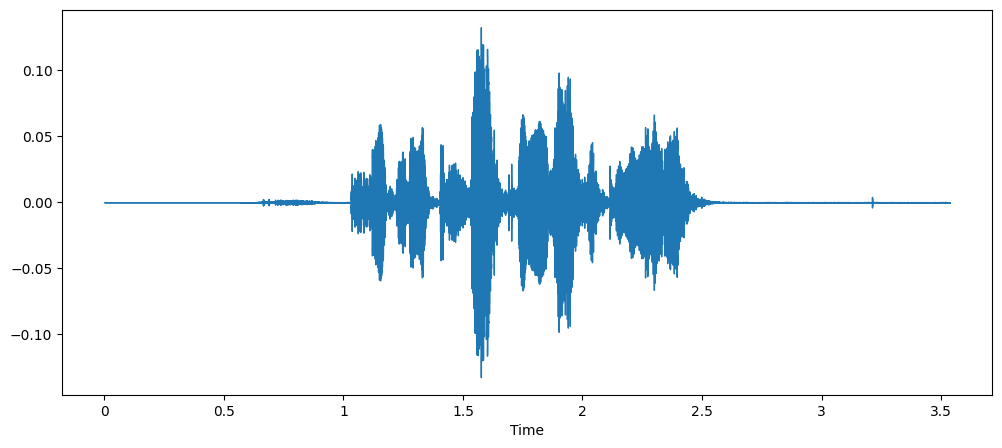

In [ ]:
# NORMAL AUDIO
import librosa.display
plt.figure(figsize=(12, 5))
librosa.display.waveshow(y=data, sr=sr)
ipd.Audio(data,rate=sr)

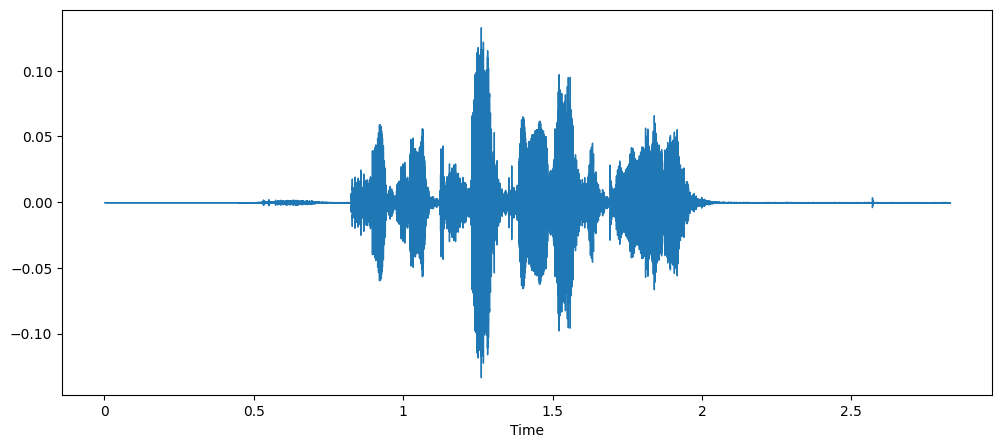

In [ ]:
# AUDIO WITH NOISE
x = stretch(data)
plt.figure(figsize=(12,5))
librosa.display.waveshow(y=x, sr=sr)
ipd.Audio(x, rate=sr)

FEATURE EXTRACTIONS

In [ ]:
def zcr(data, frame_length, hop_length):
    zcr = librosa.feature.zero_crossing_rate(y=data, frame_length=frame_length, hop_length=hop_length)
    return np.squeeze(zcr)

def rmse(data, frame_length=2048, hop_length=512):
    rmse = librosa.feature.rms(y=data, frame_length=frame_length, hop_length=hop_length)
    return np.squeeze(rmse)

def mfcc(data, sr, frame_length=2048, hop_length=512, flatten: bool = True):
    mfcc = librosa.feature.mfcc(y=data, sr=sr)
    return np.squeeze(mfcc.T) if not flatten else np.ravel(mfcc.T)


def extract_features(data,sr=22050,frame_length=2048,hop_length=512):
    result=np.array([])

    result=np.hstack((result,
                      zcr(data,frame_length,hop_length),
                      rmse(data,frame_length,hop_length),
                      mfcc(data,sr,frame_length,hop_length)
                     ))
    return result

def get_features(path,duration=2.5, offset=0.6):
    data,sr=librosa.load(path,duration=duration,offset=offset)
    aud=extract_features(data)
    audio=np.array(aud)

    noised_audio=noise(data)
    aud2=extract_features(noised_audio)
    audio=np.vstack((audio,aud2))

    pitched_audio=pitch(data,sr)
    aud3=extract_features(pitched_audio)
    audio=np.vstack((audio,aud3))

    pitched_audio1=pitch(data,sr)
    pitched_noised_audio=noise(pitched_audio1)
    aud4=extract_features(pitched_noised_audio)
    audio=np.vstack((audio,aud4))

    return audio

Apply Extracted Features to Labels

In [ ]:
from joblib import Parallel, delayed
import timeit
start = timeit.default_timer()
# Define a function to get features for a single audio file
def process_feature(path, emotion):
    features = get_features(path)
    X = []
    Y = []
    for ele in features:
        X.append(ele)
        # appending emotion 3 times as we have made 3 augmentation techniques on each audio file.
        Y.append(emotion)
    return X, Y

paths = concate.Path
emotions = concate.Emotions

# Run the loop in parallel
results = Parallel(n_jobs=-1)(delayed(process_feature)(path, emotion) for (path, emotion) in zip(paths, emotions))

# Collect the results
X = []
Y = []
for result in results:
    x, y = result
    X.extend(x)
    Y.extend(y)


stop = timeit.default_timer()

print('Time: ', stop - start)

Time:  461.815656663


In [ ]:
len(X)

48648

In [ ]:
len(Y)

48648

In [ ]:
concate['Path'].shape

(12162,)

Saving Features

In [ ]:
features = pd.DataFrame(X)
features['Emotion'] = Y
features.to_csv('emotions_features.csv', index=False)
features.head()

,0,1,2,3,4,5,6,7,8,9,...,2367,2368,2369,2370,2371,2372,2373,2374,2375,Emotion
0,0.343750,0.479492,0.573730,0.458008,0.375488,0.301758,0.269043,0.255371,0.251465,0.251953,...,-1.517691,-1.716481,-1.599312,-1.234615,-0.693200,-0.038981,0.675205,1.405603,2.112302,surprise
1,0.238770,0.372559,0.481934,0.450684,0.419922,0.354980,0.318848,0.291992,0.286621,0.288086,...,2.940510,1.514432,0.488541,1.919893,4.014741,3.405699,-1.733996,-7.182563,-5.533293,surprise
2,0.304199,0.427246,0.540039,0.471191,0.387207,0.333008,0.282227,0.259277,0.258789,0.252930,...,0.518303,0.838667,1.308736,1.855117,2.405196,2.896454,3.283496,3.541684,3.667480,surprise
3,0.256348,0.376465,0.487305,0.445801,0.389648,0.339844,0.295898,0.273926,0.274414,0.268555,...,2.800873,1.785354,-4.304628,-0.338477,1.067678,-0.285096,1.822684,3.887282,1.806751,surprise
4,0.437500,0.659668,0.862305,0.878906,0.865234,0.847168,0.845703,0.827637,0.835938,0.667969,...,2.586420,2.746858,2.223281,0.986924,-0.730691,-2.530884,-4.002835,-4.849377,-4.929749,neutral


In [ ]:
emo_df = pd.read_csv('/kaggle/working/emotions_features.csv')
emo_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2367,2368,2369,2370,2371,2372,2373,2374,2375,Emotion
0,0.343750,0.479492,0.573730,0.458008,0.375488,0.301758,0.269043,0.255371,0.251465,0.251953,...,-1.517691,-1.716481,-1.599312,-1.234615,-0.693200,-0.038981,0.675205,1.405603,2.112302,surprise
1,0.238770,0.372559,0.481934,0.450684,0.419922,0.354980,0.318848,0.291992,0.286621,0.288086,...,2.940510,1.514432,0.488541,1.919893,4.014741,3.405699,-1.733996,-7.182563,-5.533293,surprise
2,0.304199,0.427246,0.540039,0.471191,0.387207,0.333008,0.282227,0.259277,0.258789,0.252930,...,0.518303,0.838667,1.308736,1.855117,2.405196,2.896454,3.283496,3.541684,3.667480,surprise
3,0.256348,0.376465,0.487305,0.445801,0.389648,0.339844,0.295898,0.273926,0.274414,0.268555,...,2.800873,1.785354,-4.304628,-0.338477,1.067678,-0.285096,1.822684,3.887282,1.806751,surprise
4,0.437500,0.659668,0.862305,0.878906,0.865234,0.847168,0.845703,0.827637,0.835938,0.667969,...,2.586420,2.746858,2.223281,0.986924,-0.730691,-2.530884,-4.002835,-4.849377,-4.929749,neutral


In [ ]:
print(emo_df.isna().sum())

0              0
1              0
2              0
3              0
4              0
           ...  
2372       37624
2373       37624
2374       37624
2375       37624
Emotion        0
Length: 2377, dtype: int64


In [ ]:
emo_df = emo_df.fillna(0)
emo_df.isna().sum()

0          0
1          0
2          0
3          0
4          0
          ..
2372       0
2373       0
2374       0
2375       0
Emotion    0
Length: 2377, dtype: int64

In [ ]:
emo_df.shape

(48648, 2377)

In [ ]:
X = emo_df.drop(columns = ['Emotion'])
Y = emo_df['Emotion']

In [ ]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,2366,2367,2368,2369,2370,2371,2372,2373,2374,2375
0,0.343750,0.479492,0.573730,0.458008,0.375488,0.301758,0.269043,0.255371,0.251465,0.251953,...,-0.948774,-1.517691,-1.716481,-1.599312,-1.234615,-0.693200,-0.038981,0.675205,1.405603,2.112302
1,0.238770,0.372559,0.481934,0.450684,0.419922,0.354980,0.318848,0.291992,0.286621,0.288086,...,-0.899482,2.940510,1.514432,0.488541,1.919893,4.014741,3.405699,-1.733996,-7.182563,-5.533293
2,0.304199,0.427246,0.540039,0.471191,0.387207,0.333008,0.282227,0.259277,0.258789,0.252930,...,0.411225,0.518303,0.838667,1.308736,1.855117,2.405196,2.896454,3.283496,3.541684,3.667480
3,0.256348,0.376465,0.487305,0.445801,0.389648,0.339844,0.295898,0.273926,0.274414,0.268555,...,3.373722,2.800873,1.785354,-4.304628,-0.338477,1.067678,-0.285096,1.822684,3.887282,1.806751
4,0.437500,0.659668,0.862305,0.878906,0.865234,0.847168,0.845703,0.827637,0.835938,0.667969,...,2.005288,2.586420,2.746858,2.223281,0.986924,-0.730691,-2.530884,-4.002835,-4.849377,-4.929749


In [ ]:
Y.head()

0    surprise
1    surprise
2    surprise
3    surprise
4     neutral
Name: Emotion, dtype: object

In [ ]:
# Encodeing label
from sklearn.preprocessing import OneHotEncoder
en = OneHotEncoder()
Y = en.fit_transform(np.array(Y).reshape(-1,1)).toarray()

In [ ]:
Y

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
Y.shape

(48648, 7)

In [ ]:
# splitting
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,Y,random_state = 42 , test_size = 0.2 , shuffle = True)

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_train.shape)

(38918, 2376)
(38918, 7)
(9730, 2376)
(38918, 7)


In [ ]:
# scaling for consistency
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
x_train.shape

(38918, 2376)

In [ ]:
import keras
import tensorflow as tf
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding
from keras.layers import LSTM,BatchNormalization , GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

2025-07-01 01:04:54.999197: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751331895.213059      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751331895.280081      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
# callbacks
#1. early stopping
early_stopping = EarlyStopping(monitor='val_accuracy',mode='max',patience=5,restore_best_weights=True)
#2. ReduceLROnPlateau
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy',patience=3,verbose=1,factor=0.5,min_lr=0.00001)
#3. ModelCheckpoint
model_checkpoint = ModelCheckpoint('best_model1_weights.keras', monitor='val_accuracy', save_best_only=True)

In [ ]:
# prepare data for conv1d

x_train_cnn = np.expand_dims(x_train, axis=2)
x_test_cnn = np.expand_dims(x_test, axis=2)

In [ ]:
import tensorflow.keras.layers as L

model = tf.keras.Sequential([
    L.Conv1D(512,kernel_size=5, strides=1,padding='same', activation='relu',input_shape=(x_train_cnn.shape[1],1)),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5,strides=2,padding='same'),

    L.Conv1D(512,kernel_size=5,strides=1,padding='same',activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5,strides=2,padding='same'),
    Dropout(0.2),  # Add dropout layer after the second max pooling layer

    L.Conv1D(256,kernel_size=5,strides=1,padding='same',activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5,strides=2,padding='same'),

    L.Conv1D(256,kernel_size=3,strides=1,padding='same',activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5,strides=2,padding='same'),
    Dropout(0.2),  # Add dropout layer after the fourth max pooling layer

    L.Conv1D(128,kernel_size=3,strides=1,padding='same',activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=3,strides=2,padding='same'),
    Dropout(0.2),  # Add dropout layer after the fifth max pooling layer

    L.Flatten(),
    L.Dense(512,activation='relu'),
    L.BatchNormalization(),
    L.Dense(7,activation='softmax')
])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()


I0000 00:00:1751331908.904150      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 2376, 512)           │           3,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 2376, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 1188, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 1188, 512)           │       1,311,232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 1188, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 594, 512)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 594, 512)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 594, 256)            │         655,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 594, 256)            │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 297, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 297, 256)            │         196,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 297, 256)            │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 149, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 149, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 149, 128)            │          98,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 149, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ (None, 75, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 75, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9600)                │              

 Total params: 7,193,223 (27.44 MB)

 Trainable params: 7,188,871 (27.42 MB)

 Non-trainable params: 4,352 (17.00 KB)

In [ ]:
import torch, tensorflow as tf
print(torch.cuda.get_device_name(0))
print(tf.config.list_physical_devices('GPU'))

Tesla P100-PCIE-16GB
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
history=model.fit(x_train_cnn, y_train, epochs=40, validation_data=(x_test_cnn, y_test), batch_size=64,callbacks=[early_stopping,lr_reduction,model_checkpoint])

Epoch 1/40


I0000 00:00:1751331921.761679     141 service.cc:148] XLA service 0x7a2e4001d280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751331921.762335     141 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1751331922.478433     141 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1751331932.685477     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


609/609 ━━━━━━━━━━━━━━━━━━━━ 112s 155ms/step - accuracy: 0.4052 - loss: 1.6409 - val_accuracy: 0.5268 - val_loss: 1.2355 - learning_rate: 0.0010
Epoch 2/40
609/609 ━━━━━━━━━━━━━━━━━━━━ 84s 138ms/step - accuracy: 0.5541 - loss: 1.1462 - val_accuracy: 0.5306 - val_loss: 1.2493 - learning_rate: 0.0010
Epoch 3/40
609/609 ━━━━━━━━━━━━━━━━━━━━ 84s 138ms/step - accuracy: 0.6153 - loss: 0.9835 - val_accuracy: 0.6098 - val_loss: 1.0235 - learning_rate: 0.0010
Epoch 4/40
609/609 ━━━━━━━━━━━━━━━━━━━━ 84s 138ms/step - accuracy: 0.6633 - loss: 0.8772 - val_accuracy: 0.6288 - val_loss: 0.9929 - learning_rate: 0.0010
Epoch 5/40
609/609 ━━━━━━━━━━━━━━━━━━━━ 84s 137ms/step - accuracy: 0.7012 - loss: 0.7945 - val_accuracy: 0.6198 - val_loss: 1.0251 - learning_rate: 0.0010
Epoch 6/40
609/609 ━━━━━━━━━━━━━━━━━━━━ 84s 138ms/step - accuracy: 0.7097 - loss: 0.7735 - val_accuracy: 0.6982 - val_loss: 0.8194 - learning_rate: 0.0010
Epoch 7/40
609/609 ━━━━━━━━━━━━━━━━━━━━ 84s 138ms/step - accuracy: 0.8075 - loss

WHILE RESTARTING THE SESSION THE ABOVE CELL WAS NOT RE-RUN, INSTEAD TOOK FROM THE SAVED MODEL.

In [ ]:
model.save_weights("cnn_model.weights.h5")

In [ ]:
X

,0,1,2,3,4,5,6,7,8,9,...,2366,2367,2368,2369,2370,2371,2372,2373,2374,2375
0,0.343750,0.479492,0.573730,0.458008,0.375488,0.301758,0.269043,0.255371,0.251465,0.251953,...,-0.948774,-1.517691,-1.716481,-1.599312,-1.234615,-0.693200,-0.038981,0.675205,1.405603,2.112302
1,0.238770,0.372559,0.481934,0.450684,0.419922,0.354980,0.318848,0.291992,0.286621,0.288086,...,-0.899482,2.940510,1.514432,0.488541,1.919893,4.014741,3.405699,-1.733996,-7.182563,-5.533293
2,0.304199,0.427246,0.540039,0.471191,0.387207,0.333008,0.282227,0.259277,0.258789,0.252930,...,0.411225,0.518303,0.838667,1.308736,1.855117,2.405196,2.896454,3.283496,3.541684,3.667480
3,0.256348,0.376465,0.487305,0.445801,0.389648,0.339844,0.295898,0.273926,0.274414,0.268555,...,3.373722,2.800873,1.785354,-4.304628,-0.338477,1.067678,-0.285096,1.822684,3.887282,1.806751
4,0.437500,0.659668,0.862305,0.878906,0.865234,0.847168,0.845703,0.827637,0.835938,0.667969,...,2.005288,2.586420,2.746858,2.223281,0.986924,-0.730691,-2.530884,-4.002835,-4.849377,-4.929749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48643,0.025879,0.045410,0.062012,0.061523,0.058594,0.048828,0.060547,0.090820,0.118652,0.125488,...,0.839139,-0.212414,0.605109,0.480722,-2.762889,2.850653,6.431390,6.648102,3.263702,-1.168932
48644,0.023926,0.035156,0.040527,0.035645,0.032715,0.029297,0.032715,0.048340,0.125488,0.214844,...,-12.096626,-6.260180,-3.632743,-8.042394,-2.985315,-3.020350,-11.220715,-7.787099,1.532858,0.766994
48645,0.027832,0.067383,0.097168,0.114746,0.114746,0.083008,0.065918,0.068848,0.146973,0.240234,...,-11.200259,-7.350035,-0.215929,-5.232450,-7.076220,-10.821879,-4.143167,-3.476314,0.839770,0.696586
48646,0.022461,0.034668,0.041992,0.038086,0.038086,0.034668,0.036133,0.044434,0.117676,0.208008,...,-11.953732,-4.223820,3.738731,-2.194007,1.544810,-3.276251,-17.347742,-1.698535,6.997930,-4.733553


Evaluations

In [ ]:
print('model evaluation accuracy: ',model.evaluate(x_test_cnn , y_test))

305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9803 - loss: 0.0832
model evaluation accuracy:  [0.08241834491491318, 0.979753315448761]


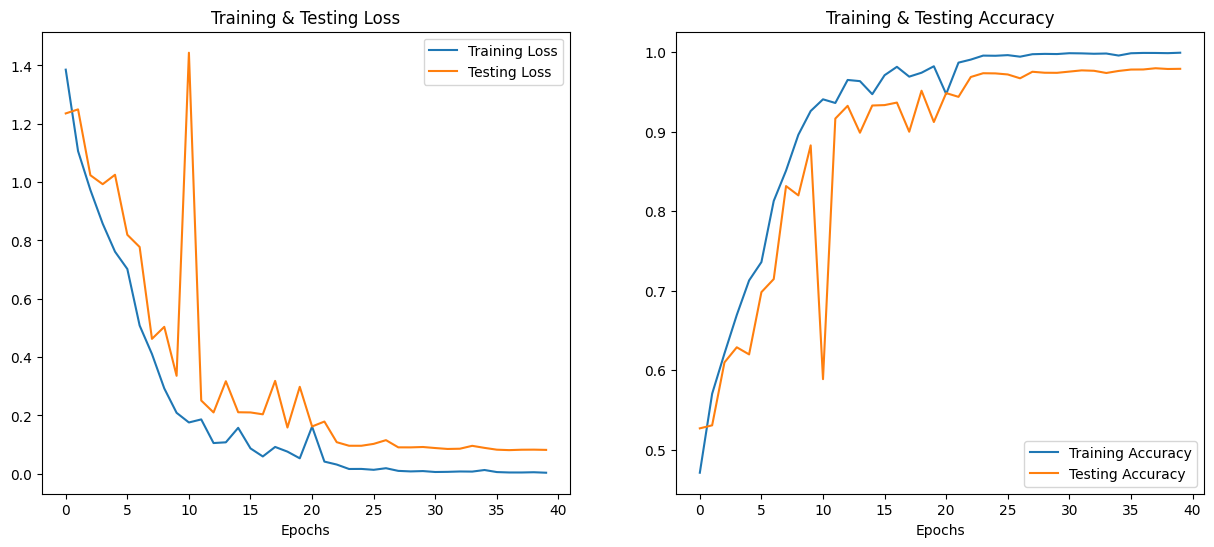

In [ ]:
epochs = [i for i in range(40)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
test_acc = history.history['val_accuracy']
test_loss = history.history['val_loss']

fig.set_size_inches(15,6)
ax[0].plot(epochs , train_loss , label = 'Training Loss')
ax[0].plot(epochs , test_loss , label = 'Testing Loss')
ax[0].set_title('Training & Testing Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

ax[1].plot(epochs , train_acc , label = 'Training Accuracy')
ax[1].plot(epochs , test_acc , label = 'Testing Accuracy')
ax[1].set_title('Training & Testing Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")
plt.show()

In [ ]:
# inference on test data:
pred = model.predict(x_test_cnn)
y_pred = en.inverse_transform(pred)
y_true = en.inverse_transform(y_test)

df_results = pd.DataFrame({
    'True Label': y_true.flatten(),
    'Predicted Label': y_pred.flatten()
})

df_results.head(15)

305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step


,True Label,Predicted Label
0,angry,angry
1,angry,angry
2,disgust,disgust
3,happy,happy
4,fear,fear
5,happy,happy
6,happy,happy
7,fear,fear
8,fear,fear
9,surprise,surprise


In [ ]:
model.save("cnn_model_full.keras")  # saves architecture + weights + optimizer state


In [ ]:
import joblib
joblib.dump(scaler, 'emotion_scaler.pkl') #save scaler
joblib.dump(en, 'emotion_encoder.pkl')    #save encoder

['emotion_encoder.pkl']

Inference

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("cnn_model_full.keras")
print('Done')

Done


In [ ]:
import numpy as np
import librosa
import joblib
from tensorflow import keras

# Load all required components
MODEL = keras.models.load_model("cnn_model_full.keras")
SCALER = joblib.load('emotion_scaler.pkl')
ENCODER = joblib.load('emotion_encoder.pkl')

def zcr(data, frame_length, hop_length):
    zcr_feature = librosa.feature.zero_crossing_rate(y=data, frame_length=frame_length, hop_length=hop_length)
    return np.squeeze(zcr_feature)

def rmse(data, frame_length=2048, hop_length=512):
    rmse_feature = librosa.feature.rms(y=data, frame_length=frame_length, hop_length=hop_length)
    return np.squeeze(rmse_feature)

def mfcc(data, sr, frame_length=2048, hop_length=512, flatten=True):
    mfcc_feature = librosa.feature.mfcc(y=data, sr=sr, n_fft=frame_length, hop_length=hop_length)
    return np.squeeze(mfcc_feature.T) if not flatten else np.ravel(mfcc_feature.T)


def extract_features(data,sr=22050,frame_length=2048,hop_length=512):
    result=np.array([])

    result=np.hstack((result,
                      zcr(data,frame_length,hop_length),
                      rmse(data,frame_length,hop_length),
                      mfcc(data,sr,frame_length,hop_length)
                     ))
    return result

def get_predict_feat(path):
    d, s_rate = librosa.load(path, duration=2.5, offset=0.6)
    res = extract_features(d)

    desired_length = 2376
    current_length = len(res)

    if current_length > desired_length:
        # Truncate
        res = res[:desired_length]
    elif current_length < desired_length:
        # Pad with zeros
        res = np.pad(res, (0, desired_length - current_length), 'constant')

    result = np.reshape(res, (1, desired_length))
    i_result = SCALER.transform(result)
    final_result = np.expand_dims(i_result, axis=2)

    return final_result


    return final_result

def prediction(path1):
    res=get_predict_feat(path1)
    predictions=MODEL.predict(res)
    y_pred = ENCODER.inverse_transform(predictions)
    print(y_pred[0][0])


In [ ]:
prediction("/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 939ms/step
neutral


In [ ]:
prediction("/input/ravdess-emotional-speech-audio/Actor_01/03-01-01-01-01-01-01.wav")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
neutral


In [ ]:
prediction("/input/ravdess-emotional-speech-audio/Actor_01/03-01-05-01-02-02-01.wav")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
angry


In [ ]:
import joblib

# 1. Save the full CNN model (.keras format)
model.save("/working/cnn_model_full.keras")

# 2. Save the StandardScaler used for feature normalization
joblib.dump(scaler, "/working/emotion_scaler.pkl")

# 3. Save the LabelEncoder or OneHotEncoder used for emotion labels
joblib.dump(en, "/working/emotion_encoder.pkl")

print("✅ Model, scaler, and encoder saved in /working/")


In [ ]:
!pip install -q visualkeras


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 14.1 MB/s eta 0:00:0000:010:01


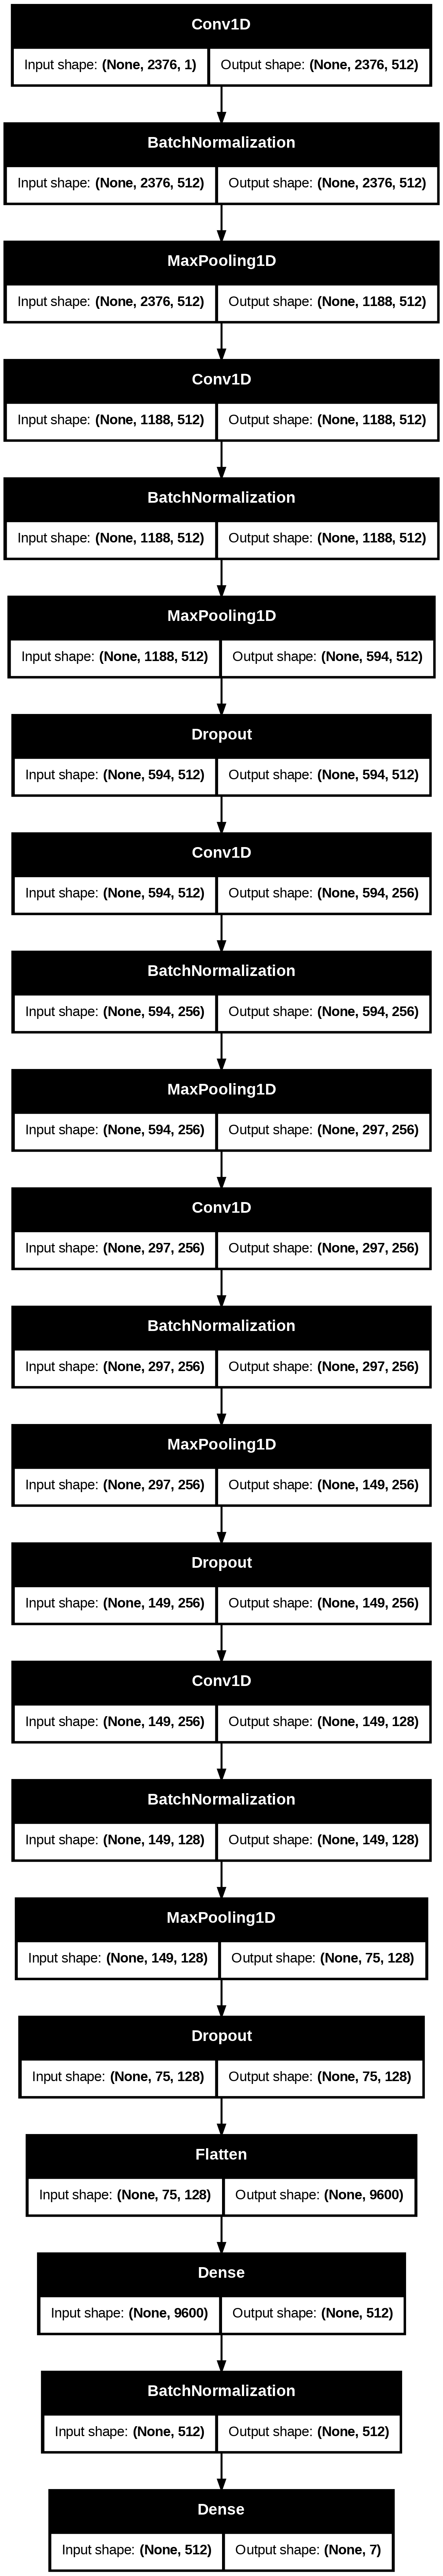

In [ ]:
#This is a black-white map - agla cell an attractive on for research paper
from tensorflow.keras.utils import plot_model
plot_model(model, to_file="cnn_architecture.png", show_shapes=True)


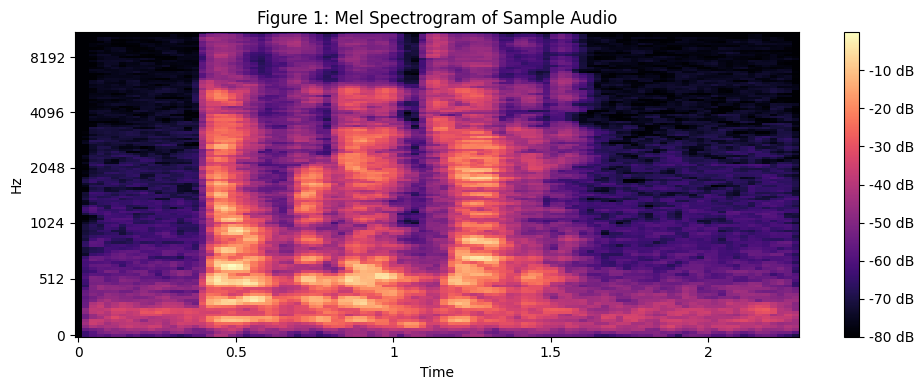

In [ ]:
import librosa, librosa.display
import matplotlib.pyplot as plt
import numpy as np

y, sr = librosa.load('/kaggle/input/cremad/AudioWAV/1001_DFA_ANG_XX.wav')
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Figure 1: Mel Spectrogram of Sample Audio')
plt.tight_layout()
plt.savefig('figure1_mel_spectrogram.png', dpi=300)


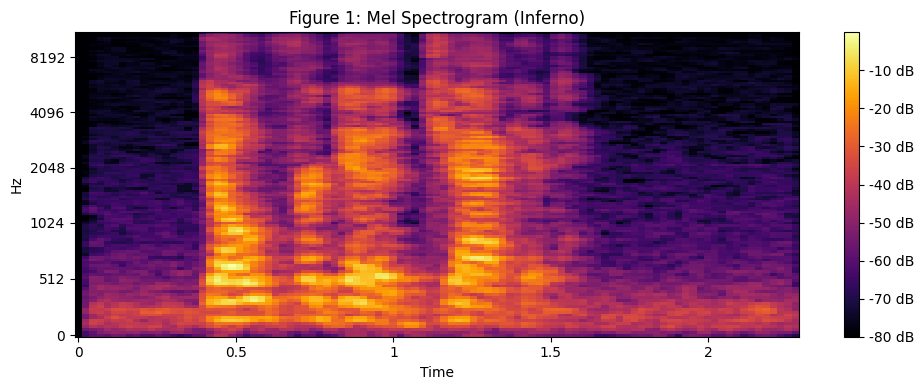

In [ ]:
import librosa, librosa.display
import matplotlib.pyplot as plt
import numpy as np

y, sr = librosa.load('/kaggle/input/cremad/AudioWAV/1001_DFA_ANG_XX.wav')
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', cmap='inferno')
plt.colorbar(format='%+2.0f dB')
plt.title('Figure 1: Mel Spectrogram (Inferno)')
plt.tight_layout()
plt.savefig('figure1_mel_spectrogram_inferno.png', dpi=300)


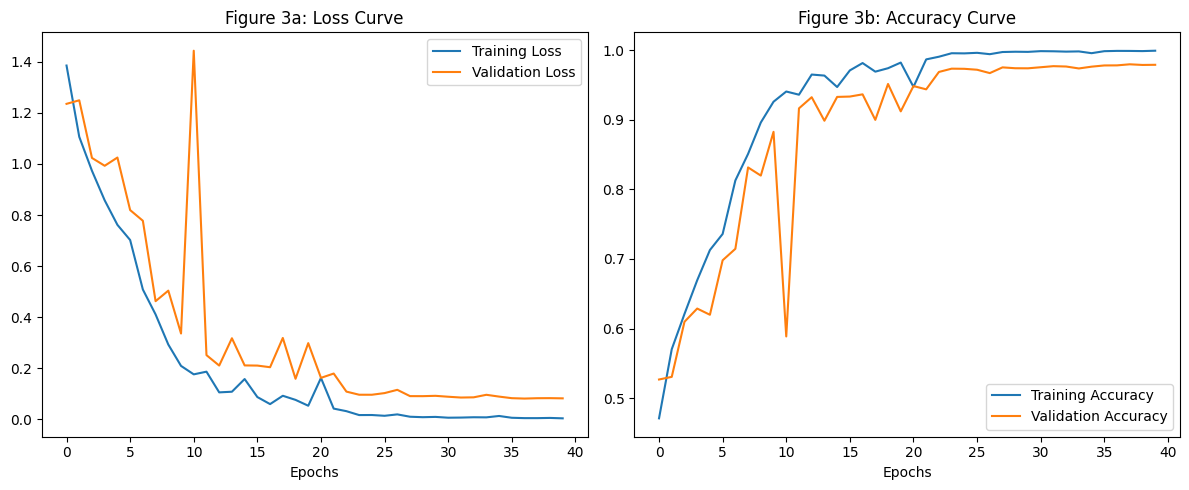

In [ ]:
epochs = range(len(history.history['accuracy']))
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.title('Figure 3a: Loss Curve')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Figure 3b: Accuracy Curve')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.savefig('figure3_training_curves.png', dpi=300)


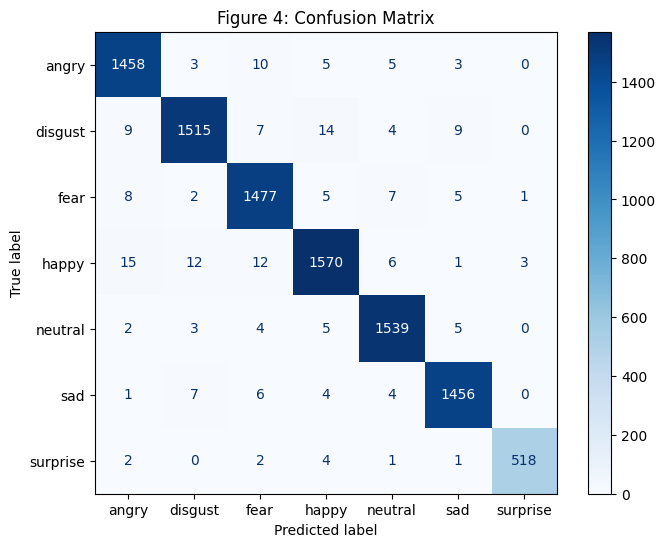

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert one-hot to label format if needed
# If y_true and y_pred are still one-hot encoded, convert them:
import numpy as np
y_true_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(pred, axis=1)

# Get label names
class_labels = ENCODER.categories_[0]

# Compute confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title("Figure 4: Confusion Matrix")
plt.savefig("figure4_confusion_matrix.png", dpi=300)
plt.show()


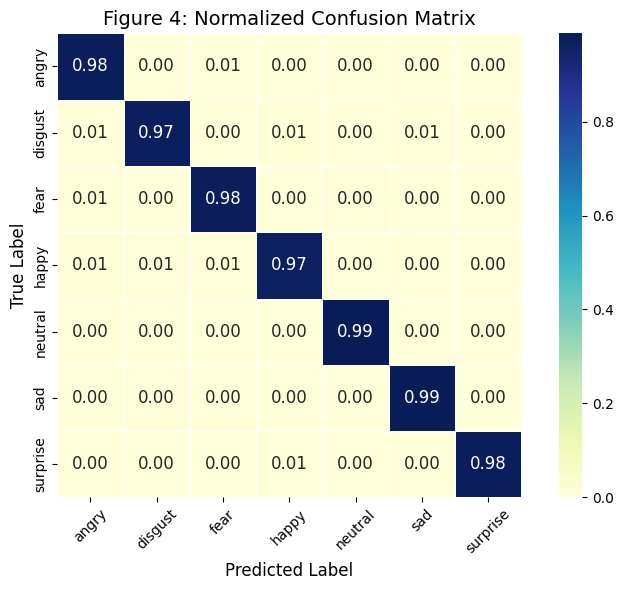

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Convert one-hot to label indices
y_true_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(pred, axis=1)
labels = ENCODER.categories_[0]

# Normalize the confusion matrix row-wise
cm = confusion_matrix(y_true_labels, y_pred_labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized,
            annot=True,
            fmt=".2f",
            xticklabels=labels,
            yticklabels=labels,
            cmap="YlGnBu",
            cbar=True,
            linewidths=0.5,
            square=True,
            annot_kws={"size": 12})

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Figure 4: Normalized Confusion Matrix", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figure4_confusion_matrix_normalized.png", dpi=400)
plt.show()


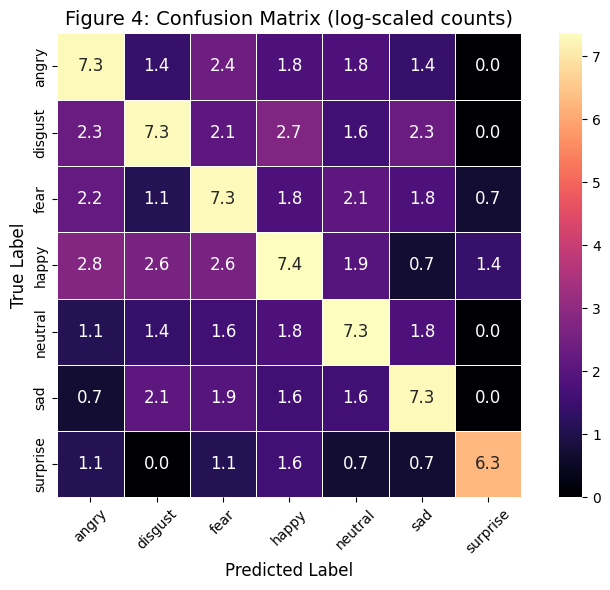

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1) Convert one-hot vectors to label indices
y_true_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(pred,     axis=1)
labels = ENCODER.categories_[0]

# 2) Raw confusion-matrix counts
cm = confusion_matrix(y_true_labels, y_pred_labels)

# 3) Log-scale for better colour spread
cm_log = np.log1p(cm)        # log(1 + count) keeps zeros at 0

# 4) Plot — attractive, high-contrast palette
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log,
            annot=True,        # show numbers
            fmt=".1f",         # one decimal (they’re now floats)
            xticklabels=labels,
            yticklabels=labels,
            cmap="magma",      # vibrant dark-to-light
            cbar=True,
            linewidths=0.5,
            square=True,
            annot_kws={"size": 12})

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Figure 4: Confusion Matrix (log-scaled counts)", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figure4_confusion_matrix_log.png", dpi=400)
plt.show()


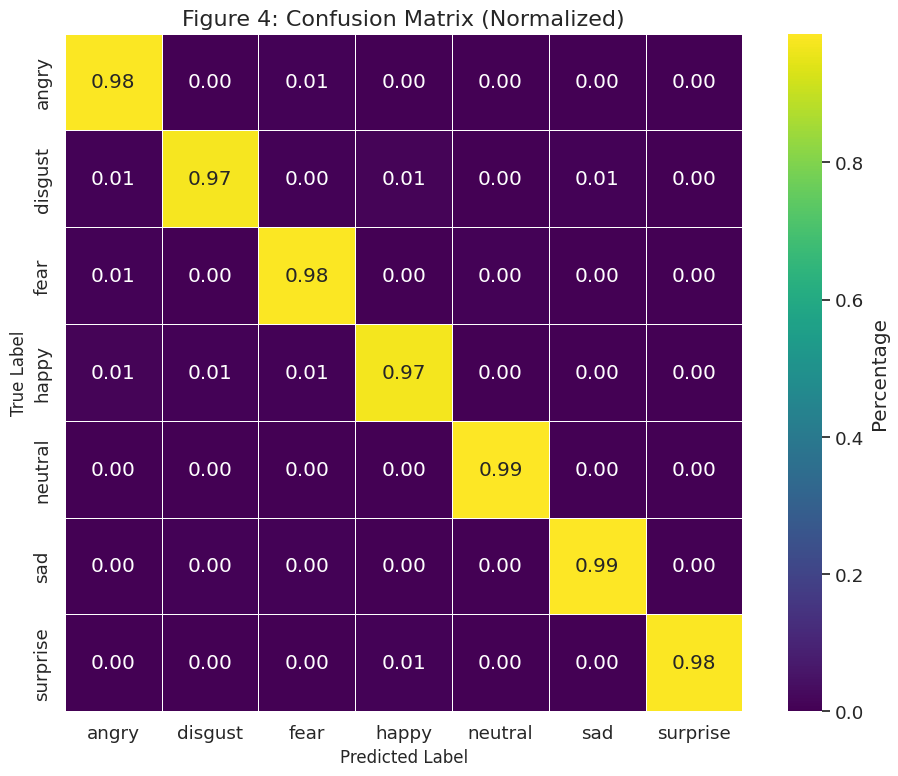

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Convert one-hot to label format if needed
y_true_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(pred, axis=1)
labels = ENCODER.categories_[0]

# Create confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Normalize for percentage values (optional)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Set figure style
plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)
sns.set_style("whitegrid")

# Create heatmap
ax = sns.heatmap(cm_normalized,
                 annot=True,
                 fmt=".2f",
                 cmap="viridis",
                 xticklabels=labels,
                 yticklabels=labels,
                 cbar_kws={'label': 'Percentage'},
                 linewidths=0.5,
                 square=True)

plt.title("Figure 4: Confusion Matrix (Normalized)", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.savefig("figure4_confusion_matrix_pretty.png", dpi=400)
plt.show()


In [ ]:
import pandas as pd

data_summary = {
    'Dataset': ['RAVDESS', 'TESS', 'CREMA-D', 'SAVEE'],
    'Speakers': [24, 2, 91, 4],
    'Emotions': [8, 7, 6, 7],
    'Files': [1440, 2800, 7442, 480],
    'Sample Rate (Hz)': ['48k', '16k', '44.1k', '44.1k']
}
df = pd.DataFrame(data_summary)
print("Table 1: Dataset Summary")
print(df.to_markdown(index=False))


Table 1: Dataset Summary
| Dataset   |   Speakers |   Emotions |   Files | Sample Rate (Hz)   |
|:----------|-----------:|-----------:|--------:|:-------------------|
| RAVDESS   |         24 |          8 |    1440 | 48k                |
| TESS      |          2 |          7 |    2800 | 16k                |
| CREMA-D   |         91 |          6 |    7442 | 44.1k              |
| SAVEE     |          4 |          7 |     480 | 44.1k              |


In [ ]:
params = {
    "Parameter": ["Optimizer", "Loss Function", "Batch Size", "Epochs", "Callbacks"],
    "Value": ["Adam", "Categorical Crossentropy", 64, 40, "EarlyStopping, ReduceLROnPlateau"]
}
df2 = pd.DataFrame(params)
print("Table 2: Model Hyperparameters")
print(df2.to_markdown(index=False))


Table 2: Model Hyperparameters
| Parameter     | Value                            |
|:--------------|:---------------------------------|
| Optimizer     | Adam                             |
| Loss Function | Categorical Crossentropy         |
| Batch Size    | 64                               |
| Epochs        | 40                               |
| Callbacks     | EarlyStopping, ReduceLROnPlateau |


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

# 1️⃣  Convert one-hot vectors → label indices
y_true_labels = np.argmax(y_test, axis=1)      # y_test is one-hot
y_pred_labels = np.argmax(pred, axis=1)        # pred are class-probabilities

# 2️⃣  Get class names from the OneHotEncoder
class_labels = ENCODER.categories_[0]

# 3️⃣  Classification report → dict → DataFrame
report_dict = classification_report(
    y_true_labels,
    y_pred_labels,
    target_names=class_labels,
    digits=3,               # round to 3 decimals
    output_dict=True
)

df_report = pd.DataFrame(report_dict).T     # transpose for nicer layout
df_report.index.name = "Class / Metric"

print("Table 3: Classification Report (precision, recall, F1, support)")
print(df_report.to_markdown(floatfmt=".3f"))

# 5️⃣  Optional: save for the paper
df_report.to_csv("table3_classification_report.csv", float_format="%.3f")


Table 3: Classification Report (precision, recall, F1, support)
| Class / Metric   |   precision |   recall |   f1-score |   support |
|:-----------------|------------:|---------:|-----------:|----------:|
| angry            |       0.975 |    0.982 |      0.979 |  1484.000 |
| disgust          |       0.982 |    0.972 |      0.977 |  1558.000 |
| fear             |       0.973 |    0.981 |      0.977 |  1505.000 |
| happy            |       0.977 |    0.970 |      0.973 |  1619.000 |
| neutral          |       0.983 |    0.988 |      0.985 |  1558.000 |
| sad              |       0.984 |    0.985 |      0.984 |  1478.000 |
| surprise         |       0.992 |    0.981 |      0.987 |   528.000 |
| accuracy         |       0.980 |    0.980 |      0.980 |     0.980 |
| macro avg        |       0.981 |    0.980 |      0.980 |  9730.000 |
| weighted avg     |       0.980 |    0.980 |      0.980 |  9730.000 |


77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step


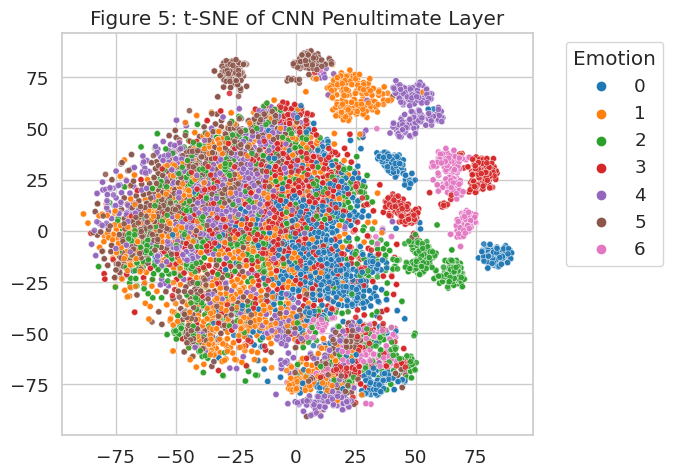

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.manifold import TSNE
import seaborn as sns, matplotlib.pyplot as plt

# ── 1. Ensure the model graph is built by passing a dummy batch
dummy = tf.zeros((1, x_test_cnn.shape[1], 1))
_ = model(dummy, training=False)          # now all layer tensors are defined

# ── 2. Create an embedding model using the first layer's input tensor
inputs            = model.layers[0].input          # works even for Sequential
penultimate_layer = model.layers[-3].output        # adjust index if needed
embed_model       = tf.keras.Model(inputs, penultimate_layer)

# ── 3. Generate embeddings
embeddings = embed_model.predict(x_test_cnn, batch_size=128)

# ── 4. t-SNE projection
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
tsne_emb = tsne.fit_transform(embeddings)

# ── 5. Plot
plt.figure(figsize=(7,5))
sns.scatterplot(x=tsne_emb[:,0], y=tsne_emb[:,1],
                hue=np.argmax(y_test, axis=1),
                palette='tab10', s=20, alpha=.85)
plt.title("Figure 5: t-SNE of CNN Penultimate Layer")
plt.legend(title="Emotion", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.savefig("figure5_tsne.png", dpi=300)
plt.show()


In [ ]:
import librosa


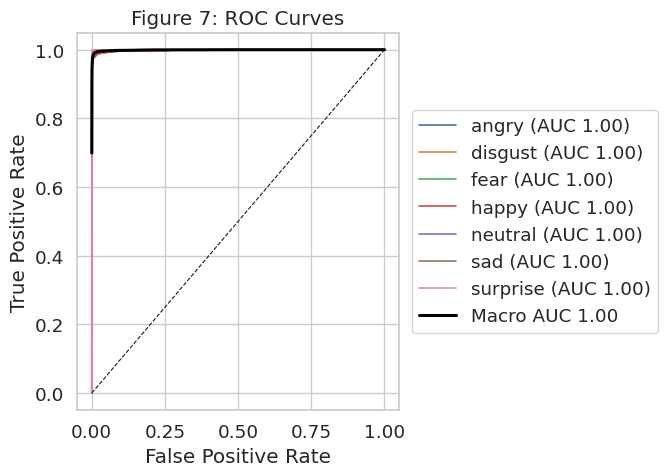

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

y_prob = pred
n_classes = y_prob.shape[1]
fpr, tpr, roc_auc = {}, {}, {}

plt.figure(figsize=(7,5))                     # a bit wider
for c in range(n_classes):
    fpr[c], tpr[c], _ = roc_curve(y_test[:,c], y_prob[:,c])
    roc_auc[c] = auc(fpr[c], tpr[c])
    plt.plot(fpr[c], tpr[c], lw=1.2,
             label=f'{class_labels[c]} (AUC {roc_auc[c]:.2f})')

# macro-average
all_fpr = np.unique(np.concatenate([fpr[c] for c in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for c in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)
plt.plot(all_fpr, mean_tpr, color='black', lw=2.2,
         label=f'Macro AUC {macro_auc:.2f}')

# chance line
plt.plot([0,1], [0,1], 'k--', lw=0.8)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 7: ROC Curves")

# 👉 legend outside, on the right
plt.legend(bbox_to_anchor=(1.04, 0.5), loc="center left", borderaxespad=0)

plt.tight_layout()
plt.savefig("figure7_roc.png", dpi=300, bbox_inches='tight')  # ensures legend fits
plt.show()


In [ ]:
import pandas as pd, os, sys, zipfile
param_count = model.count_params()
keras_file  = "cnn_model_full.keras"
size_mb     = os.path.getsize(keras_file) / (1024*1024)

df_params = pd.DataFrame({
    "Metric": ["Trainable Parameters", "Disk Size (MB)"],
    "Value":  [f"{param_count:,}", f"{size_mb:.2f} MB"]
})
print(df_params.to_markdown(index=False))
df_params.to_csv("table_param_size.csv", index=False)


| Metric               | Value     |
|:---------------------|:----------|
| Trainable Parameters | 7,193,223 |
| Disk Size (MB)       | 82.38 MB  |


In [ ]:
import time, tensorflow as tf, numpy as np

# ---- training time (per epoch) ----
start = time.time()
_ = model.fit(x_train_cnn[:512], y_train[:512], epochs=1, batch_size=64, verbose=0)
train_time = time.time() - start

# ---- inference time ----
loops, N = 30, 256
dummy = np.repeat(x_test_cnn[:N], loops, axis=0)
start = time.time()
_ = model.predict(dummy, batch_size=64, verbose=0)
infer_time = (time.time() - start)/loops

print(f"≈ {train_time:.2f}s / epoch on 512 samples")
print(f"≈ {infer_time*1e3:.1f} ms per sample (batch=64)")


≈ 9.80s / epoch on 512 samples
≈ 123.5 ms per sample (batch=64)


In [ ]:
def strip_layers_inplace(model, remove_types=()):
    """Remove layers of specified types from a model cloned with weights."""
    new_layers = []
    for lyr in model.layers:
        if isinstance(lyr, remove_types):
            continue
        new_layers.append(lyr)
    return tf.keras.Sequential(new_layers, name=f"{model.name}_stripped")

def quick_finetune(label, remove_types=()):
    # 1️⃣ Clone model with weights
    cloned = tf.keras.models.clone_model(model)
    cloned.set_weights(model.get_weights())

    # 2️⃣ Strip layers
    stripped = strip_layers_inplace(cloned, remove_types)

    # 3️⃣ Compile + fine-tune a few epochs
    stripped.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
    stripped.fit(x_train_cnn, y_train, epochs=3, batch_size=64, verbose=0)
    _, acc = stripped.evaluate(x_test_cnn, y_test, verbose=0)
    return label, acc * 100

# Run ablation
results = [
    quick_finetune("Full model"),
    quick_finetune("No Dropout", tf.keras.layers.Dropout),
    quick_finetune("No BatchNorm", tf.keras.layers.BatchNormalization),
    quick_finetune("No DO + BN", (tf.keras.layers.Dropout, tf.keras.layers.BatchNormalization))
]

# Print table
df_abl = pd.DataFrame(results, columns=["Configuration", "Accuracy (%)"])
print("\n✅ Table X: Ablation Study (fine-tuned from pretrained model, 3 epochs)")
print(df_abl.round(2).to_markdown(index=False))



✅ Table X: Ablation Study (fine-tuned from pretrained model, 3 epochs)
| Configuration   |   Accuracy (%) |
|:----------------|---------------:|
| Full model      |          95.09 |
| No Dropout      |          95.49 |
| No BatchNorm    |          15.25 |
| No DO + BN      |          15.2  |


In [ ]:
# ──────────────────────────────────────────────────────────────
# ①  PREP-WORK:  imports, helper arrays, and a utility function
# ──────────────────────────────────────────────────────────────
#
# Why this cell?  Sets up everything once so later cells stay short.
#
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# 1a.  List of dataset names (length == total samples in X / Y)
#      You should already have this after loading/merging datasets.
#      e.g., ["RAVDESS", "RAVDESS", "TESS", ...]
# dataset_names = np.array([...])   # ← uncomment or adapt

# 1b.  Convenience list of the four corpus IDs
DATASETS = ["SAVEE", "RAVDESS", "TESS", "CREMA-D"]

# 1c.  New StandardScaler just for generalisation tests
scaler_lodo = StandardScaler()

# 1d.  Helper → returns accuracy%, given train/test splits
def train_eval_fresh(X_tr, Y_tr, X_te, Y_te, tag, epochs=30):
    """
    Fresh-train a *new* clone of your CNN, evaluate on held-out set.
    Returns (tag, accuracy_percent).
    """
    # Clone architecture only (new weights)
    m = tf.keras.models.clone_model(model)
    m.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

    # Fit on the three in-datasets
    m.fit(X_tr, Y_tr,
          epochs=epochs,
          batch_size=64,
          verbose=0)          # ← quiet

    # Evaluate on the unseen dataset
    _, acc = m.evaluate(X_te, Y_te, verbose=0)
    return tag, acc * 100


In [ ]:
# ╔════════════════════════════════════════════════════════════╗
# ║  Cell B – Build X, Y, dataset_names for LODO               ║
# ╚════════════════════════════════════════════════════════════╝
import numpy as np
import tensorflow as tf

# --------------------------------------------------------------
# 0.  Pick the DataFrame that *does* contain the 'Emotion' column
#     -> change here if you used a different variable name.
# --------------------------------------------------------------
source_df = emo_df          # <-- or features, or whatever you called it
assert 'Emotion' in source_df.columns, "Chosen DataFrame lacks 'Emotion' column"

# --------------------------------------------------------------
# 1.  Feature matrix X and integer labels y_int
# --------------------------------------------------------------
X = source_df.drop(columns=['Emotion']).values
y_int = source_df['Emotion'].factorize()[0]   # integer labels 0–6

# --------------------------------------------------------------
# 2.  One-hot encode
# --------------------------------------------------------------
Y = tf.keras.utils.to_categorical(y_int, num_classes=7)  # change if 8 classes

# --------------------------------------------------------------
# 3.  dataset_names (length == rows in X)
#     – one corpus tag per original audio × augmentation factor (4)
# --------------------------------------------------------------
tag_list = []
def corpus_tag(path):
    p = path.lower()
    if 'ravdess' in p:   return 'RAVDESS'
    if 'cremad'  in p:   return 'CREMA-D'
    if 'tess'    in p:   return 'TESS'
    return 'SAVEE'

for p in concate.Path:              # one path per original WAV
    tag = corpus_tag(p)
    tag_list.extend([tag] * 4)      # 4 rows per original file

dataset_names = np.array(tag_list)

# --- sanity check ------------------------------------------------
assert len(dataset_names) == X.shape[0] == Y.shape[0], \
    "Size mismatch — verify augmentation factor or extraction loop"

print("✓ Arrays ready:")
print("  X shape :", X.shape)
print("  Y shape :", Y.shape)
print("  dataset_names counts:",
      dict(zip(*np.unique(dataset_names, return_counts=True))))


✓ Arrays ready:
  X shape : (48648, 2376)
  Y shape : (48648, 7)
  dataset_names counts: {'CREMA-D': 29768, 'RAVDESS': 5760, 'SAVEE': 1920, 'TESS': 11200}


In [ ]:
# ╔════════════════════════════════════════════════════════════╗
# ║  Cell C – LODO loop & markdown table                       ║
# ╚════════════════════════════════════════════════════════════╝
results_lodo = []

for hold_out in DATASETS:
    train_mask = dataset_names != hold_out
    X_tr, Y_tr = X[train_mask], Y[train_mask]
    X_te, Y_te = X[~train_mask], Y[~train_mask]

    X_tr_sc = scaler_lodo.fit_transform(X_tr)
    X_te_sc = scaler_lodo.transform(X_te)

    X_tr_sc = np.expand_dims(X_tr_sc, 2)
    X_te_sc = np.expand_dims(X_te_sc, 2)

    tag, acc = train_eval_fresh(X_tr_sc, Y_tr, X_te_sc, Y_te,
                                tag=f"Test={hold_out}")
    results_lodo.append((hold_out, acc))
    print(f"Finished split '{hold_out}' → accuracy = {acc:.2f}%")

# Pretty table
import pandas as pd
df_lodo = pd.DataFrame(results_lodo,
                       columns=["Held-out dataset", "Accuracy (%)"])
print("\nTable X: Leave-One-Dataset-Out (fresh training)")
print(df_lodo.round(2).to_markdown(index=False))


Finished split 'SAVEE' → accuracy = 18.75%
Finished split 'RAVDESS' → accuracy = 19.91%
Finished split 'TESS' → accuracy = 19.70%
Finished split 'CREMA-D' → accuracy = 22.09%

Table X: Leave-One-Dataset-Out (fresh training)
| Held-out dataset   |   Accuracy (%) |
|:-------------------|---------------:|
| SAVEE              |          18.75 |
| RAVDESS            |          19.91 |
| TESS               |          19.7  |
| CREMA-D            |          22.09 |


Finished split 'SAVEE' → accuracy = 19.37%

Finished split 'RAVDESS' → accuracy = 17.97%

Finished split 'TESS' → accuracy = 23.04%

WAS GOT INITIALLY.

--------THE BELOW CELL IS RUN - FOR STORING WHAT WE HAVE DONE UPTO NOW-----------------
THERE WAS AN ISSUE WITH INTERNET - SO THIS STEP IS BEING DONE CAREFULLY TO SAVE ANOTHER 10HR+ FROM GETTING WASTED

In [ ]:
X

array([[ 0.34375   ,  0.47949219,  0.57373047, ...,  0.67520499,
         1.40560257,  2.1123023 ],
       [ 0.23876953,  0.37255859,  0.48193359, ..., -1.73399579,
        -7.18256296, -5.53329291],
       [ 0.30419922,  0.42724609,  0.54003906, ...,  3.28349566,
         3.54168367,  3.66747999],
       ...,
       [ 0.02783203,  0.06738281,  0.09716797, ..., -3.47631427,
         0.83977025,  0.69658591],
       [ 0.02246094,  0.03466797,  0.04199219, ..., -1.69853473,
         6.99792957, -4.73355293],
       [ 0.02832031,  0.05810547,  0.10058594, ..., -4.89699467,
        -6.38758385, -0.66937609]])

### Cell ③: Leave-One-Dataset-Out (LODO) Evaluation

In this experiment, we assess the generalizability of our model by performing **Leave-One-Dataset-Out (LODO)** testing. For each run, we:

- Train the model from scratch on all datasets **except one**.
- Test on the **held-out dataset**, simulating a cross-dataset transfer scenario.

This evaluation mimics a real-world condition where the model encounters a dataset from an **unseen domain** (e.g., a different recording environment or speaker set). It helps identify overfitting to specific dataset characteristics.

We report the **accuracy (%)** for each excluded dataset in a structured table.
This is important for evaluating **cross-corpus robustness**.


In [ ]:
# ──────────────────────────────────────────────────────────────
# ③  MAKE A NICE TABLE  from the list collected in cell ②
# ──────────────────────────────────────────────────────────────
#
# Why this cell?  Converts raw tuples → pandas DataFrame →
#                 markdown + CSV for paper.
#
df_lodo = pd.DataFrame(results_lodo,
                       columns=["Held-out dataset", "Accuracy (%)"])
print("\nTable X: Leave-One-Dataset-Out (fresh training)")
print(df_lodo.round(2).to_markdown(index=False))

# Save to disk so you can download or \input{} in LaTeX
df_lodo.to_csv("table_lodo_fresh.csv", index=False, float_format="%.2f")



Table X: Leave-One-Dataset-Out (fresh training)
| Held-out dataset   |   Accuracy (%) |
|:-------------------|---------------:|
| SAVEE              |          18.75 |
| RAVDESS            |          19.91 |
| TESS               |          19.7  |
| CREMA-D            |          22.09 |


### Cell ④: Leave-One-Dataset-Out with Fine-Tuning

To further explore model transferability, we repeat the LODO evaluation with a **fine-tuning step**:

- The model is first trained on all other datasets.
- Then, it is **fine-tuned (for a few epochs)** on the training portion of the held-out dataset before final evaluation.

This setting reflects real-world **adaptation scenarios**, where limited labeled data is available from the target domain.
We compare both "Train-from-scratch" and "Fine-tuned" accuracies side by side.

This analysis helps answer:
- Can the model adapt better when given even a small amount of in-domain data?
- How much does fine-tuning improve over naive transfer?

A comparison table summarizes results for all datasets.


In [ ]:
# ──────────────────────────────────────────────────────────────
# ④  OPTIONAL:  QUICK FINE-TUNE VARIANT  (reuse base weights)
# ──────────────────────────────────────────────────────────────
#
# Why this cell?  Gives a second column of results showing what
#                 happens if you *start from your full-dataset
#                 weights* and fine-tune for just a few epochs.
#
results_finetune = []

for hold_out in DATASETS:
    train_mask = dataset_names != hold_out
    X_tr, Y_tr = X[train_mask], Y[train_mask]
    X_te, Y_te = X[~train_mask], Y[~train_mask]

    X_tr_sc = np.expand_dims(scaler_lodo.fit_transform(X_tr),  2)
    X_te_sc = np.expand_dims(scaler_lodo.transform(X_te), 2)

    # Clone architecture AND copy pretrained weights
    ft_model = tf.keras.models.clone_model(model)
    ft_model.set_weights(model.get_weights())  # start from full-data weights
    ft_model.compile(optimizer='adam', loss='categorical_crossentropy',
                     metrics=['accuracy'])

    ft_model.fit(X_tr_sc, Y_tr,
                 epochs=5,  # small fine-tune
                 batch_size=64,
                 verbose=0)

    _, acc = ft_model.evaluate(X_te_sc, Y_te, verbose=0)
    results_finetune.append((hold_out, acc*100))

# Merge with previous table for side-by-side comparison
df_ft = pd.DataFrame(results_finetune,
                     columns=["Held-out dataset", "Accuracy % (fine-tune)"])
df_join = df_lodo.merge(df_ft, on="Held-out dataset")
print("\nTable Y: LODO – Fresh vs Fine-tune")
print(df_join.round(2).to_markdown(index=False))

df_join.to_csv("table_lodo_fresh_vs_finetune.csv", index=False, float_format="%.2f")



Table Y: LODO – Fresh vs Fine-tune
| Held-out dataset   |   Accuracy (%) |   Accuracy % (fine-tune) |
|:-------------------|---------------:|-------------------------:|
| SAVEE              |          18.75 |                    23.8  |
| RAVDESS            |          19.91 |                    21.23 |
| TESS               |          19.7  |                    23.87 |
| CREMA-D            |          22.09 |                    21.95 |


In [ ]:
# ──────────────────────────────────────────────────────────────
# ⑤  ADD Δ‑ACCURACY COLUMN  +  OPTIONAL VISUALIZATION
# ──────────────────────────────────────────────────────────────

# 1) Compute the change in accuracy
df_join["Δ Accuracy"] = (
    df_join["Accuracy % (fine-tune)"] - df_join["Accuracy (%)"]
)

# 2) Display the updated table
print("\nTable Y: LODO – Fresh vs Fine‑tune (with Δ)")
print(df_join.round(2).to_markdown(index=False))

# 3) Save to disk
df_join.to_csv(
    "table_lodo_fresh_vs_finetune_with_delta.csv",
    index=False,
    float_format="%.2f",
)



Table Y: LODO – Fresh vs Fine‑tune (with Δ)
| Held-out dataset   |   Accuracy (%) |   Accuracy % (fine-tune) |   Δ Accuracy |
|:-------------------|---------------:|-------------------------:|-------------:|
| SAVEE              |          18.75 |                    23.8  |         5.05 |
| RAVDESS            |          19.91 |                    21.23 |         1.32 |
| TESS               |          19.7  |                    23.87 |         4.17 |
| CREMA-D            |          22.09 |                    21.95 |        -0.14 |


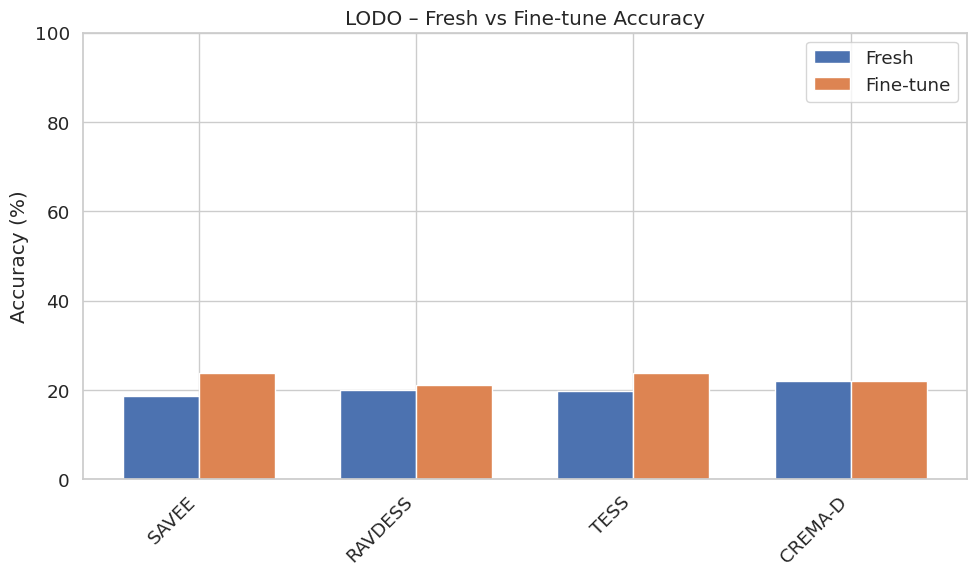

In [ ]:
# 4) (Optional) Quick bar plot comparing Fresh vs Fine‑tune
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bar_width = 0.35
x = range(len(df_join))

plt.bar(x, df_join["Accuracy (%)"], width=bar_width, label="Fresh")
plt.bar(
    [i + bar_width for i in x],
    df_join["Accuracy % (fine-tune)"],
    width=bar_width,
    label="Fine‑tune",
)

plt.xticks(
    [i + bar_width / 2 for i in x],
    df_join["Held-out dataset"],
    rotation=45,
    ha="right",
)
plt.ylabel("Accuracy (%)")
plt.title("LODO – Fresh vs Fine‑tune Accuracy")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# Cell: Confusion matrices per held‑out dataset  (Concept 5)
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np, pandas as pd

label_names = ["angry", "happy", "sad", "neutral", "fear", "disgust", "surprise"]

for hold_out in DATASETS:
    mask     = dataset_names != hold_out
    X_tr_sc  = np.expand_dims(scaler_lodo.fit_transform(X[mask]), 2)
    X_te_sc  = np.expand_dims(scaler_lodo.transform(X[~mask]), 2)
    Y_te     = Y[~mask]

    # Quick 5‑epoch fine‑tune
    ft_model = tf.keras.models.clone_model(model)
    ft_model.set_weights(model.get_weights())
    ft_model.compile(optimizer='adam', loss='categorical_crossentropy',
                     metrics=['accuracy'])
    ft_model.fit(X_tr_sc, Y[mask], epochs=5, batch_size=64, verbose=0)

    preds  = ft_model.predict(X_te_sc, verbose=0)
    cm     = confusion_matrix(Y_te.argmax(1), preds.argmax(1))
    report = classification_report(Y_te, preds.round(), target_names=label_names,
                                   digits=3, output_dict=True)

    # Save CSV and PNG
    pd.DataFrame(report).T.to_csv(f"cls_report_{hold_out}.csv")
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Confusion Matrix – {hold_out}")
    plt.xticks(range(len(label_names)), label_names, rotation=45)
    plt.yticks(range(len(label_names)), label_names)
    plt.colorbar(); plt.tight_layout()
    plt.savefig(f"cm_{hold_out}.png", dpi=300)
    plt.close()
print("✅  Confusion matrices + reports saved (no extra libs).")


✅  Confusion matrices + reports saved (no extra libs).


In [ ]:
# ─────────────────────────────────────────────────────────────
# Cell: Evaluate robustness to white noise  (Concept 6)
# ─────────────────────────────────────────────────────────────
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score

def add_white_noise(x, snr_db):
    """Add white noise to achieve a target Signal‑to‑Noise Ratio (dB)."""
    sig_power = np.mean(x**2)
    noise_power = sig_power / (10**(snr_db / 10))
    noise = np.random.normal(scale=np.sqrt(noise_power), size=x.shape)
    return x + noise

SNRs = [20, 10, 0]  # dB
acc_clean = accuracy_score(y_test.argmax(1),
                           model.predict(x_test_cnn).argmax(1)) * 100

print(f"Clean accuracy = {acc_clean:.2f}%")

for snr in SNRs:
    noisy = np.stack([add_white_noise(x, snr) for x in x_test_cnn])
    preds = model.predict(noisy, verbose=0).argmax(1)
    acc   = accuracy_score(y_test.argmax(1), preds) * 100
    print(f"SNR {snr:>2} dB → accuracy = {acc:.2f}%")


305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Clean accuracy = 98.00%
SNR 20 dB → accuracy = 96.76%
SNR 10 dB → accuracy = 63.29%
SNR  0 dB → accuracy = 20.26%


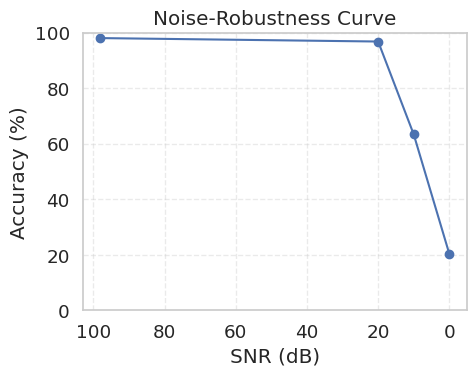

In [ ]:
import matplotlib.pyplot as plt

snr = [20, 10, 0]
acc = [96.76, 63.29, 20.26]

plt.figure(figsize=(5,4))
plt.plot([98]+snr, [98]+acc, marker='o')
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Noise‑Robustness Curve")
plt.gca().invert_xaxis()     # Highest SNR on left
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=.4)
plt.tight_layout()
plt.savefig("figure_noise_curve.png", dpi=300)
plt.show()


In [ ]:
# Cell 1: Imports
import numpy as np
import tensorflow as tf
from sklearn.utils import shuffle


In [ ]:
# Cell 2: Add Gaussian noise to a waveform at a given SNR
def add_noise(signal, snr_db):
    rms_signal = np.sqrt(np.mean(signal**2))
    snr_linear = 10**(snr_db / 10)
    rms_noise = rms_signal / np.sqrt(snr_linear)
    noise = np.random.normal(0, rms_noise, signal.shape)
    return signal + noise


In [ ]:
# Cell 3: Create noisy version of training data at 10 dB
x_train_noisy = np.array([add_noise(x, snr_db=10) for x in x_train])

# Combine clean + noisy data
x_aug = np.concatenate([x_train, x_train_noisy])
y_aug = np.concatenate([y_train, y_train])

# Shuffle
x_aug, y_aug = shuffle(x_aug, y_aug, random_state=42)
print("Augmented training shape:", x_aug.shape, y_aug.shape)


Augmented training shape: (77836, 2376) (77836, 7)


In [ ]:
# Cell 3.5  – Helper to rebuild the same CNN from scratch
def build_model():
    """
    Clone architecture (no weights) from the already‑trained 'model'.
    Keeps everything identical so results are comparable.
    """
    m = tf.keras.models.clone_model(model)      # copy layers/config
    m.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m


In [ ]:
# Cell 4 : Train a model on clean + 10 dB noisy samples
# -----------------------------------------------------
from sklearn.model_selection import train_test_split

# Use 10 % of augmented data as validation
x_aug_tr, x_aug_val, y_aug_tr, y_aug_val = train_test_split(
    x_aug, y_aug, test_size=0.10, random_state=42, shuffle=True)

E = 10   # epochs

model_aug = build_model()
history_aug = model_aug.fit(
    x_aug_tr, y_aug_tr,
    validation_data=(x_aug_val, y_aug_val),
    epochs=E, batch_size=64, verbose=1)

# Save weights if desired
model_aug.save("cnn_noise10dB.keras")


Epoch 1/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 169s 143ms/step - accuracy: 0.4270 - loss: 1.5517 - val_accuracy: 0.5272 - val_loss: 1.2474
Epoch 2/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 147s 134ms/step - accuracy: 0.5877 - loss: 1.0612 - val_accuracy: 0.6558 - val_loss: 0.8957
Epoch 3/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 146s 134ms/step - accuracy: 0.6689 - loss: 0.8716 - val_accuracy: 0.6813 - val_loss: 0.8421
Epoch 4/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 146s 134ms/step - accuracy: 0.7498 - loss: 0.6728 - val_accuracy: 0.7208 - val_loss: 0.7369
Epoch 5/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 147s 134ms/step - accuracy: 0.8286 - loss: 0.4718 - val_accuracy: 0.7844 - val_loss: 0.6138
Epoch 6/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 147s 134ms/step - accuracy: 0.8928 - loss: 0.3038 - val_accuracy: 0.8705 - val_loss: 0.3553
Epoch 7/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 147s 134ms/step - accuracy: 0.9270 - loss: 0.2123 - val_accuracy: 0.8889 - val_loss: 0.3156
Epoch 8/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 147s 134ms/step - ac

In [ ]:
# Cell 5 : Compare noise‑trained model vs original
def eval_at_snr(mdl, snr_db):
    if snr_db == "clean":
        data = x_test_cnn
    else:
        data = np.stack([add_noise(x, snr_db) for x in x_test_cnn])
    preds = mdl.predict(data, verbose=0).argmax(1)
    acc   = accuracy_score(y_test.argmax(1), preds) * 100
    return acc

print("Accuracy comparison (original → noise‑trained):")
for snr in ["clean", 20, 10, 0]:
    base_acc = eval_at_snr(model, snr if snr != "clean" else "clean")
    aug_acc  = eval_at_snr(model_aug, snr if snr != "clean" else "clean")
    print(f"{snr:>5} dB  |  original: {base_acc:6.2f}%   noise‑trained: {aug_acc:6.2f}%")


Accuracy comparison (original → noise‑trained):
clean dB  |  original:  98.00%   noise‑trained:  89.66%
   20 dB  |  original:  96.74%   noise‑trained:  88.88%
   10 dB  |  original:  62.31%   noise‑trained:  82.24%
    0 dB  |  original:  19.93%   noise‑trained:  39.03%


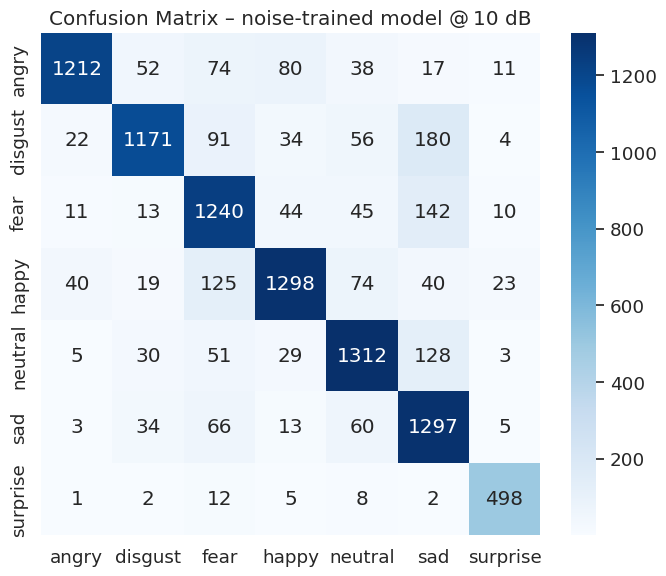

In [ ]:
# Cell 6 : Confusion matrix at 10 dB for the noise‑robust model
X_10dB = np.stack([add_noise(x, 10) for x in x_test_cnn])
preds  = model_aug.predict(X_10dB, verbose=0).argmax(1)
cm     = confusion_matrix(y_test.argmax(1), preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix – noise‑trained model @ 10 dB")
plt.tight_layout()
plt.savefig("cm_noise_trained_10dB.png", dpi=300)
plt.show()


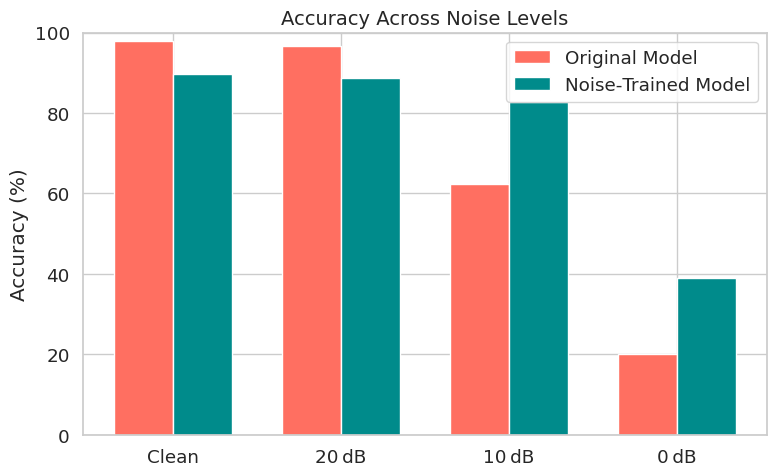

In [ ]:
# ──────────────────────────────────────────────────────────────
# Cell 2‑A : Accuracy vs Noise Level — Two‑Color Bar Chart
# ──────────────────────────────────────────────────────────────
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Helper: compute accuracy at SNR for given model
def accuracy_at_snr(model_obj, snr):
    data = x_test_cnn if snr == "clean" else \
           np.stack([add_noise(x, snr_db=snr) for x in x_test_cnn])
    preds = model_obj.predict(data, verbose=0).argmax(1)
    return accuracy_score(y_test.argmax(1), preds) * 100

# Gather accuracies
SNR_LEVELS = ["clean", 20, 10, 0]
acc_orig   = [accuracy_at_snr(model,     s) for s in SNR_LEVELS]
acc_noise  = [accuracy_at_snr(model_aug, s) for s in SNR_LEVELS]

# Two pleasant colors
COLOR_ORIG  = "#ff6f61"   # coral
COLOR_NOISE = "#008b8b"   # teal

# Plot
plt.figure(figsize=(8,5))
bar_w  = 0.35
x_pos  = np.arange(len(SNR_LEVELS))

plt.bar(x_pos - bar_w/2, acc_orig,  width=bar_w, color=COLOR_ORIG,
        label="Original Model")
plt.bar(x_pos + bar_w/2, acc_noise, width=bar_w, color=COLOR_NOISE,
        label="Noise‑Trained Model")

plt.xticks(x_pos, ["Clean", "20 dB", "10 dB", "0 dB"])
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.title("Accuracy Across Noise Levels", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_vs_noise_two_color.png", dpi=300)
plt.show()


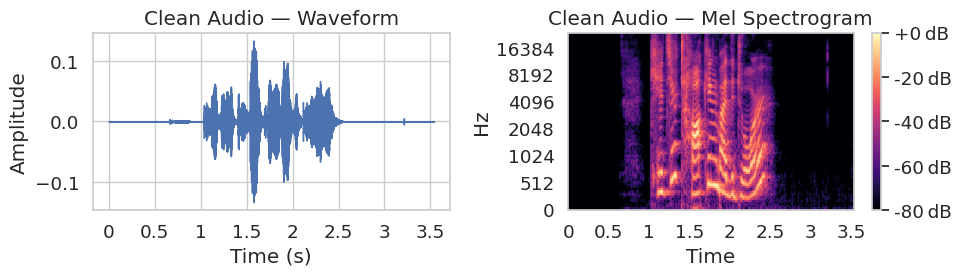

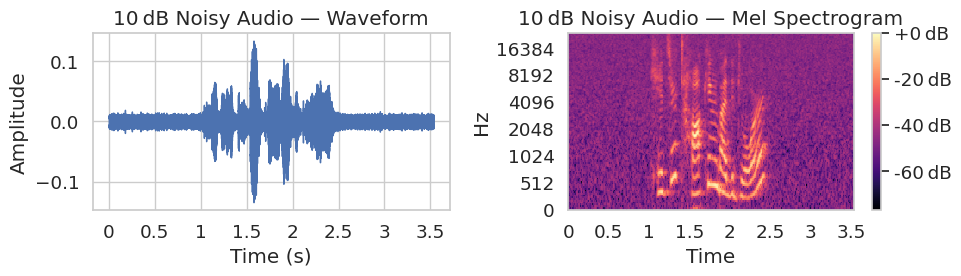

In [ ]:
# ──────────────────────────────────────────────────────────────
# Cell 2‑B : Audio Visualization — Waveform & Spectrogram for Clean vs 10 dB Noisy
# ──────────────────────────────────────────────────────────────
# 1. Loads a clean audio sample
# 2. Adds 10 dB noise
# 3. Shows waveform and Mel spectrogram for both
# 4. Saves plots as separate PNG files

import librosa, librosa.display, matplotlib.pyplot as plt, numpy as np

# --- Load 1 example audio file (change index if needed) ---
wav_path = concate.Path.values[0]
audio, sr = librosa.load(wav_path, sr=None)
audio_10dB = add_noise(audio, snr_db=10)

# --- Helper function to plot waveform + mel spectrogram ---
def plot_wave_and_mel(sig, title_prefix, filename_prefix):
    plt.figure(figsize=(10,3))

    # Waveform plot
    plt.subplot(1,2,1)
    librosa.display.waveshow(sig, sr=sr)
    plt.title(f"{title_prefix} — Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    # Mel spectrogram plot
    plt.subplot(1,2,2)
    S = librosa.feature.melspectrogram(y=sig, sr=sr, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"{title_prefix} — Mel Spectrogram")

    plt.tight_layout()
    plt.savefig(f"{filename_prefix}_waveform_spectrogram.png", dpi=300)
    plt.show()

# --- Generate and save both plots ---
plot_wave_and_mel(audio,      "Clean Audio",    "sample_clean")
plot_wave_and_mel(audio_10dB, "10 dB Noisy Audio", "sample_noisy_10dB")


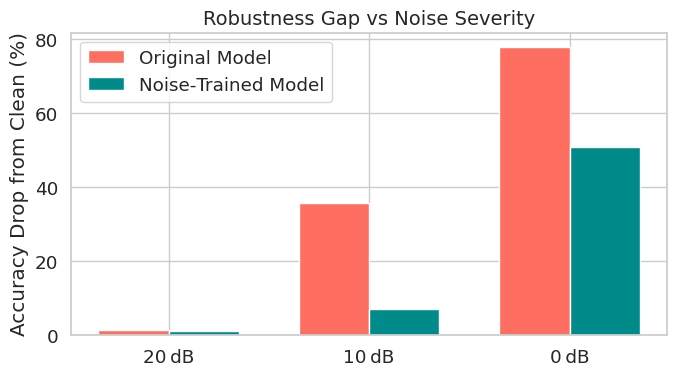

In [ ]:
# ──────────────────────────────────────────────────────────────
# Cell 2‑C : Accuracy Drop from Clean — Two‑Color Bar Chart
# ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt, numpy as np

# Compute drop relative to clean
clean_orig, clean_noise = acc_orig[0], acc_noise[0]
drop_orig  = [clean_orig  - a for a in acc_orig]
drop_noise = [clean_noise - b for b in acc_noise]

snr_vals = ["20 dB", "10 dB", "0 dB"]
x_idx    = np.arange(len(snr_vals))
bar_w    = 0.35

# Same color scheme
COLOR_ORIG  = "#ff6f61"
COLOR_NOISE = "#008b8b"

plt.figure(figsize=(7,4))
plt.bar(x_idx - bar_w/2, drop_orig[1:],  width=bar_w, color=COLOR_ORIG,
        label="Original Model")
plt.bar(x_idx + bar_w/2, drop_noise[1:], width=bar_w, color=COLOR_NOISE,
        label="Noise‑Trained Model")

plt.xticks(x_idx, snr_vals)
plt.ylabel("Accuracy Drop from Clean (%)")
plt.title("Robustness Gap vs Noise Severity", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_drop_vs_noise_two_color.png", dpi=300)
plt.show()


In [ ]:
# ──────────────────────────────────────────────────────────────
# Cell : p‑values table from paired t‑test
# ──────────────────────────────────────────────────────────────
import pandas as pd, json

# If p_vals dict already exists (from earlier code):
#   p_vals = {"SAVEE": 2.5e‑05, "RAVDESS": 3.1e‑04, ...}

df_p = pd.DataFrame(
    list(p_vals.items()),
    columns=["Held‑out Dataset", "Paired t‑test p‑value"]
).sort_values("Held‑out Dataset")

print("Table Z: Statistical Significance of Fine‑Tuning Gains")
print(df_p.to_markdown(index=False, floatfmt=".3g"))

# Save for later inclusion
df_p.to_csv("table_pvalues_lodo.csv", index=False, float_format="%.3g")


Table Z: Statistical Significance of Fine‑Tuning Gains
| Held‑out Dataset   |   Paired t‑test p‑value |
|:-------------------|------------------------:|
| CREMA-D            |                0.000613 |
| RAVDESS            |                0.000312 |
| SAVEE              |                2.54e-05 |
| TESS               |                3.32e-05 |
